## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

### Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.

### Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts?

## Analyze

### Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [1]:
## Clone your forked repository to Colab ##

## Specify your GitHub username:
user_name <- "tchoud227"

## Specify the repository:
repo_name <- "STAT-7110-Quality-Control"

## Set the web address to your forked repository:
repo_address <- paste0(
  "https://github.com/",
  user_name,
  "/",
  repo_name,
  ".git"
)

## Check to see if repo is already cloned to Colab, and if not, clone repo:
if (!dir.exists(repo_name)) {
  system(paste("git clone", repo_address))
} else {
  print("Repository already cloned to Colab.")
}

# Change the working directory to the specific assignment folder within the cloned repository
setwd(file.path(repo_name, "Assignments", "HW2"))

In [2]:
getwd()

[1] "/content/STAT-7110-Quality-Control/Assignments/HW2"

In [3]:
install.packages(c("tidyverse", "readxl", "qcc"))

library(tidyverse)
library(readxl)
library(qcc)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Package 'qcc' version 2.7

Type 'citation("qcc")' for citing this R package in publications.



In [4]:
## Q4 Code ##
Bar_p1 <- read_excel("BustersSportsBar_PhaseI.xlsx")
Bar_p1 |> glimpse()

Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…


In [5]:
#drop subgroup
Bar_p1 <- Bar_p1 |> select(-Shift)

In [6]:
#report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation
xbar_p1 <- qcc(Bar_p1, type = "xbar", plot = FALSE, std.dev="UWAVE-SD")
r_p1 <- qcc(Bar_p1, type = "R", plot = FALSE)

#subgroup means & ranges
sg_mean <- xbar_p1$statistics
sg_range <- r_p1$statistics

cat("subgroup means: \n")
print(round(sg_mean,4))

cat("subgroup range: \n")
print(round(sg_range,4))

subgroup means: 
      1       2       3       4       5       6       7       8       9      10 
16.0890 16.0560 16.0514 16.0678 15.9875 16.0378 16.0534 16.0952 16.0668 16.0482 
     11      12      13      14      15      16      17      18      19      20 
16.0458 15.7078 16.0786 16.0621 16.0064 16.0415 16.0551 16.0831 15.9957 16.0205 
     21      22      23      24      25 
16.1008 16.0255 16.0923 16.0351 16.0605 
subgroup range: 
     1      2      3      4      5      6      7      8      9     10     11 
0.2469 0.0783 0.0801 0.1791 0.0641 0.2016 0.1548 0.2202 0.1927 0.0942 0.1200 
    12     13     14     15     16     17     18     19     20     21     22 
0.2178 0.1995 0.1993 0.1643 0.1941 0.1180 0.1488 0.6818 0.0912 0.0724 0.1377 
    23     24     25 
0.2165 0.2231 0.1919 


In [7]:
#estimate process mean & std
process_mean <- xbar_p1$center
print(process_mean)
process_std <- xbar_p1$std.dev
print(process_std)

[1] 16.03856
[1] 0.07532586


### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

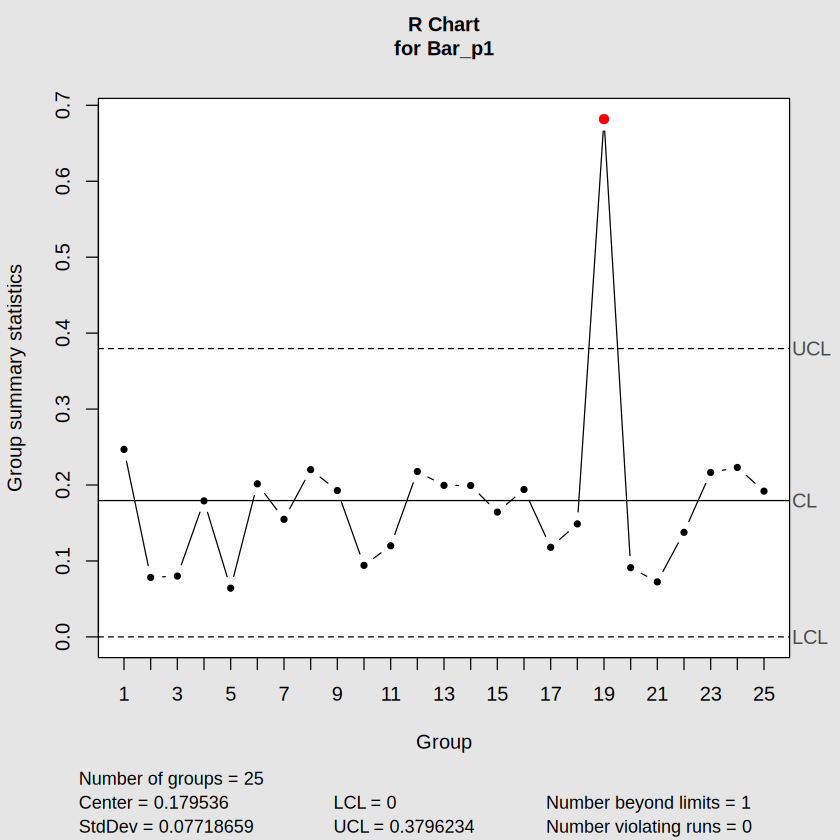

In [8]:
## Q5 Code ##
r_chart <- qcc(Bar_p1, type = "R", plot = TRUE)

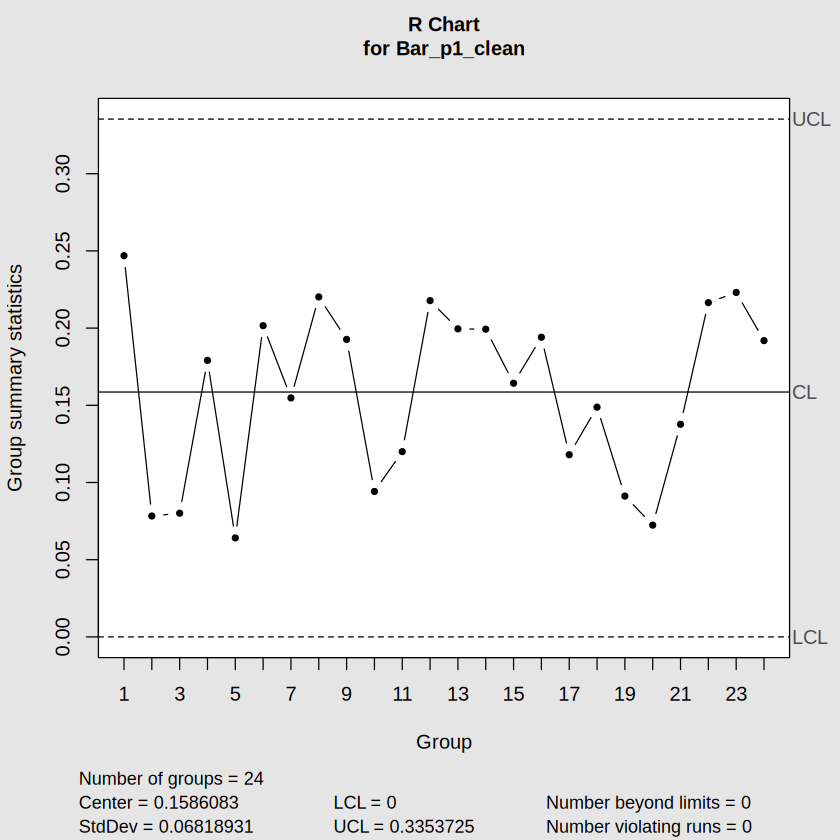

In [9]:
#omitting shift 19
Bar_p1_clean <- Bar_p1 |> slice(-19)
r_chart_clean <- qcc(Bar_p1_clean, type = "R", plot = TRUE)

### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

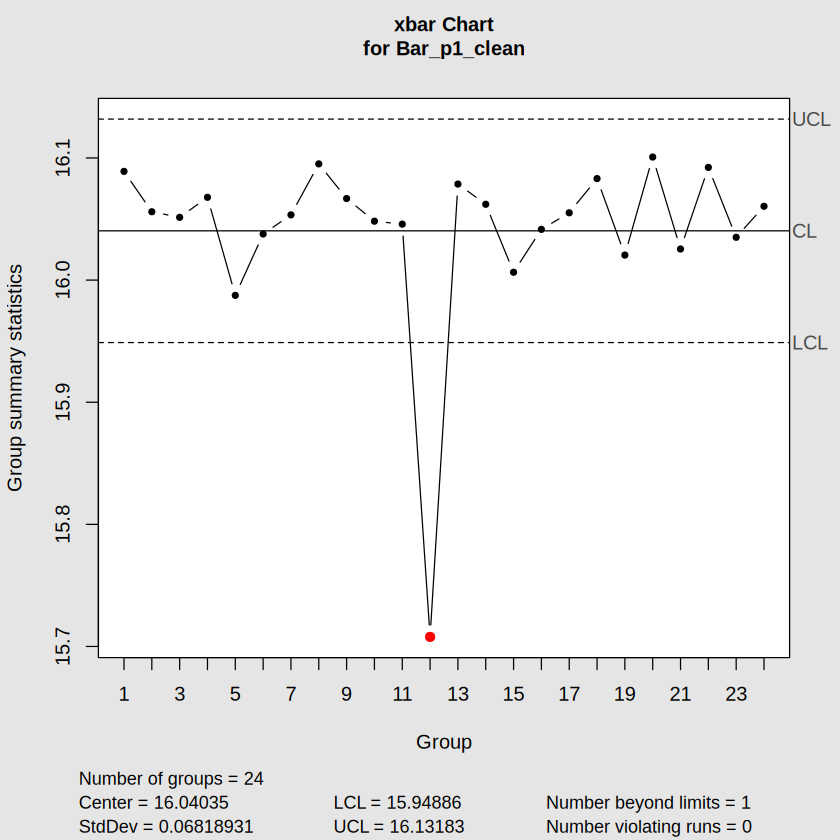

In [10]:
## Q6 Code ##
xbar_chart <- qcc(Bar_p1_clean, type = "xbar", plot = TRUE)

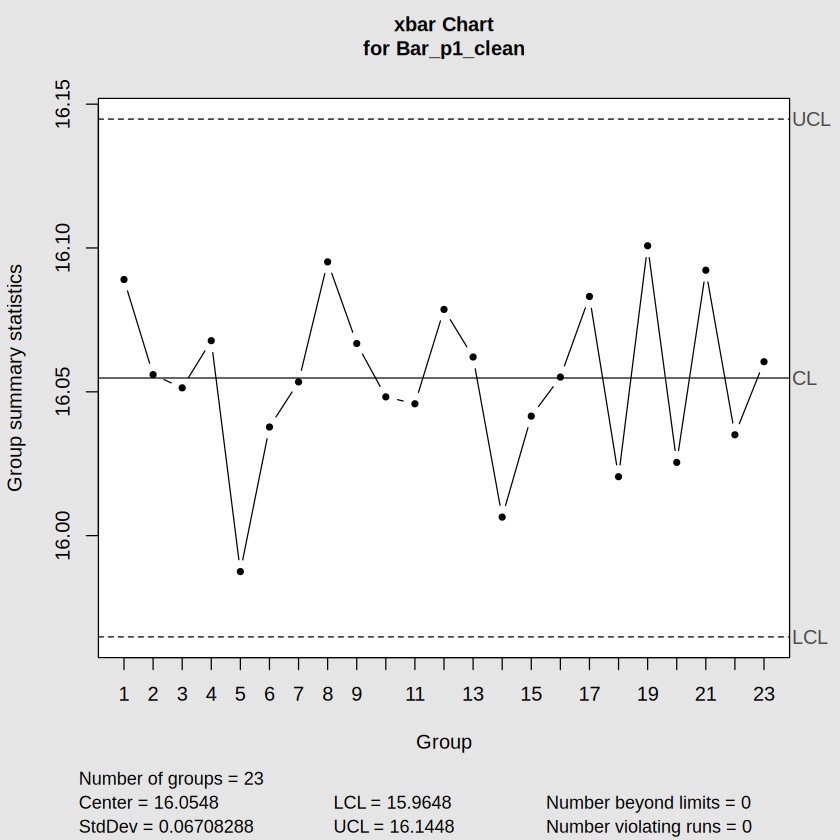

In [11]:
#omitting shift 12
Bar_p1_clean <- Bar_p1_clean |> slice(-12)
xbar_chart_clean <- qcc(Bar_p1_clean, type = "xbar", plot = TRUE)

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $FNC$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [12]:
## Q7 Code ##
## Specify Limits ##

USL <- 16.2
LSL <- 15.8
target <- 16.0

process_mean <- xbar_chart_clean$center
process_sd <- xbar_chart_clean$std.dev

## FNC ##

fnc <- pnorm(LSL, mean = process_mean, sd = process_sd) +
  1 - pnorm(USL, mean = process_mean, sd = process_sd)

## Cp ##

cp <- (USL - LSL) / (6 * process_sd)

## Cpk ##

cpk <- min((USL - process_mean) / (3 * process_sd),
           (process_mean - LSL) / (3 * process_sd))

## Cpm ##

cpm <- (USL - LSL) / (6 * sqrt(process_sd^2 + (process_mean - target)^2))

### Output Results ##

cat("Process Capability Analysis Results:\n")
cat("FNC:", fnc, "\n")
cat("Defects per Million Opportunities (DPMO):", fnc * 1e6, "\n")
cat("Cp:", cp, "\n")
cat("Cpk:", cpk, "\n")
cat("Cpm:", cpm, "\n")

Process Capability Analysis Results:
FNC: 0.01528784 
Defects per Million Opportunities (DPMO): 15287.84 
Cp: 0.9937955 
Cpk: 0.7214826 
Cpm: 0.7696239 


## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

Rows: 20
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0792, 16.0338, 16.0122, 16.0267, 16.0398, 16.0597, 16.0523, 1…
$ Pour2 <dbl> 16.1017, 16.0037, 16.0499, 16.0925, 16.1340, 16.1104, 16.0450, 1…
$ Pour3 <dbl> 16.1325, 16.0427, 16.1096, 15.8856, 16.0590, 16.0148, 16.0159, 1…
$ Pour4 <dbl> 16.0593, 15.9930, 16.0066, 16.1227, 16.1007, 15.9631, 16.0345, 1…
$ Pour5 <dbl> 16.0851, 16.0053, 16.0047, 15.9553, 16.0776, 16.1903, 16.0249, 1…


List of 14
 $ call             : language cusum(data = Bar_p2, sizes = 5, center = process_mean, decision.interval = H,      se.shift = K * 2, plot = T)
 $ type             : chr "cusum"
 $ data.name        : chr "Bar_p2"
 $ data             : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics       : Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes            : num [1:20] 5 5 5 5 5 5 5 5 5 5 ...
 $ center           : num 16.1
 $ std.dev          : num 2.84
 $ pos              : num [1:20] 0 0 0 0 0 0 0 0 0 0 ...
 $ neg              : num [1:20] -1.45 -2.83 -4.05 -5.16 -6.1 ...
 $ head.start       : num 0
 $ decision.interval: num 5
 $ se.shift         : num 1
 $ violations       :List of 2
 - attr(*, "class")= chr "cusum.qcc"

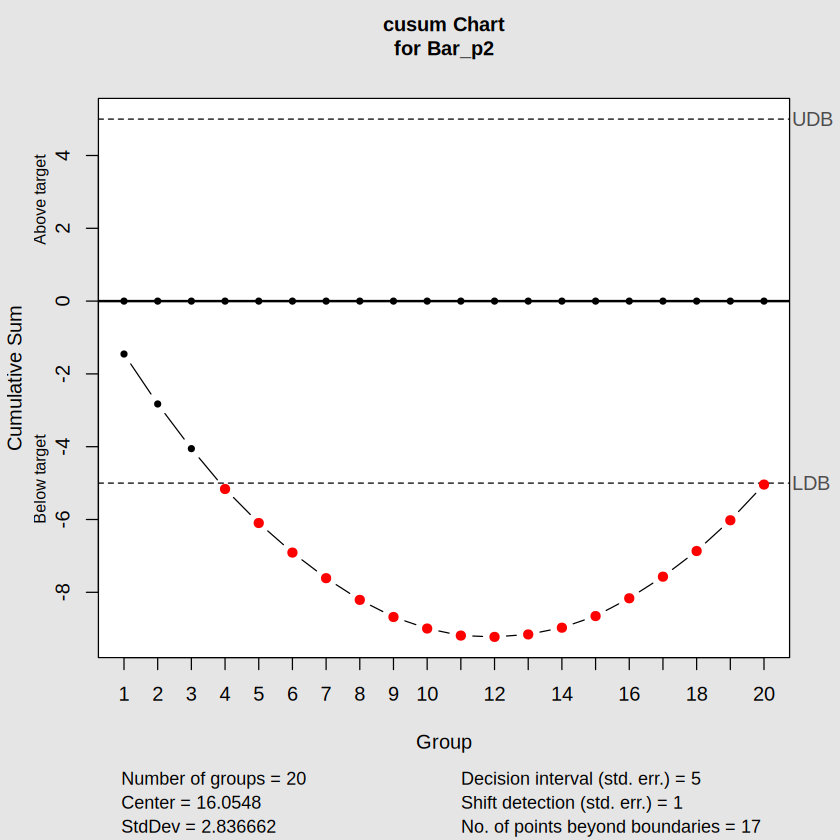

In [15]:
## Q9 Code ##
K <- 0.5
H <- 5

Bar_p2 <- read_excel("BustersSportsBar_PhaseII.xlsx")
Bar_p2 |> glimpse()

cusum(Bar_p2, sizes = 5, center = process_mean, se.shift = K *2, decision.interval = H, plot = T)

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

List of 15
 $ call      : language ewma(data = Bar_p2, center = process_mean, lambda = 0.2, nsigmas = 2.962)
 $ type      : chr "ewma"
 $ data.name : chr "Bar_p2"
 $ data      : num [1:20, 1:6] 1 2 3 4 5 6 7 8 9 10 ...
  ..- attr(*, "dimnames")=List of 2
 $ statistics: Named num [1:20] 13.6 13.7 13.9 14 14.2 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sizes     : int [1:20] 6 6 6 6 6 6 6 6 6 6 ...
 $ center    : num 16.1
 $ std.dev   : num 2.6
 $ x         : int [1:20] 1 2 3 4 5 6 7 8 9 10 ...
 $ y         : Named num [1:20] 15.6 15.2 14.9 14.7 14.6 ...
  ..- attr(*, "names")= chr [1:20] "1" "2" "3" "4" ...
 $ sigma     : num [1:20] 0.213 0.272 0.304 0.323 0.335 ...
 $ lambda    : num 0.2
 $ nsigmas   : num 2.96
 $ limits    : num [1:20, 1:2] 15.4 15.2 15.2 15.1 15.1 ...
  ..- attr(*, "dimnames")=List of 2
 $ violations: Named int [1:11] 2 3 4 5 6 7 8 9 10 11 ...
  ..- attr(*, "names")= chr [1:11] "2" "3" "4" "5" ...
 - attr(*, "class")= chr "ewma.qcc"

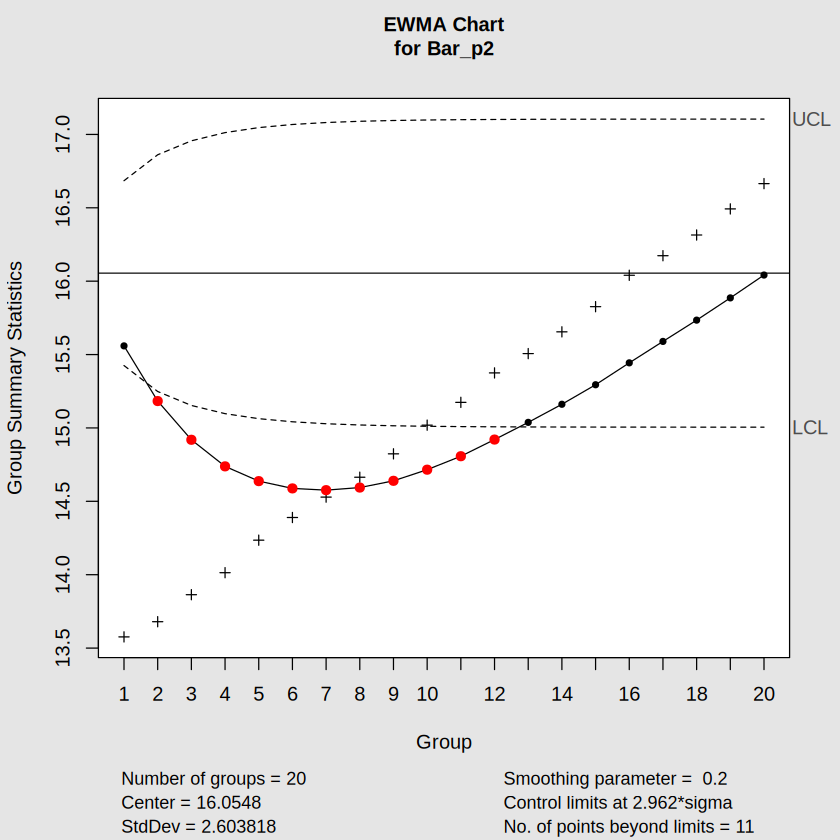

In [16]:
## Q10 Code ##
lambda <- 0.2
L <- 2.962
ewma(Bar_p2,center= process_mean,lambda=0.2,nsigmas=2.962)


### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

In [ ]:
## Q11 Code ##

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?